In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import os
print(os.getcwd())

import warnings
warnings.filterwarnings('ignore')


C:\Users\HP\projects\loan approval prediction


step 1 - Gathering data

In [2]:
df=pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')
df['Loan_Status'] = df['ApplicantIncome'].apply(lambda x: 1 if x > 5000 else 0)

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,1
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,0
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,0
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban,0
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban,0
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban,0
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban,0
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural,0


step 2 - EDA read and explore data

In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,367.000000,367.000000,362.000000,361.000000,338.000000,367.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444,0.256131
std,4910.685399,2334.232099,61.366652,65.156643,0.380150,0.437091
min,0.000000,0.000000,28.000000,6.000000,0.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000,0.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000,0.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000,1.000000


In [5]:
df.isna().sum()*100/len(df) #percentage of missing values in every column

Loan_ID              0.000000
Gender               2.997275
Married              0.000000
Dependents           2.724796
Education            0.000000
Self_Employed        6.267030
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           1.362398
Loan_Amount_Term     1.634877
Credit_History       7.901907
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

step 3 - missing values imputation

1.Gender

<Axes: xlabel='Gender', ylabel='count'>

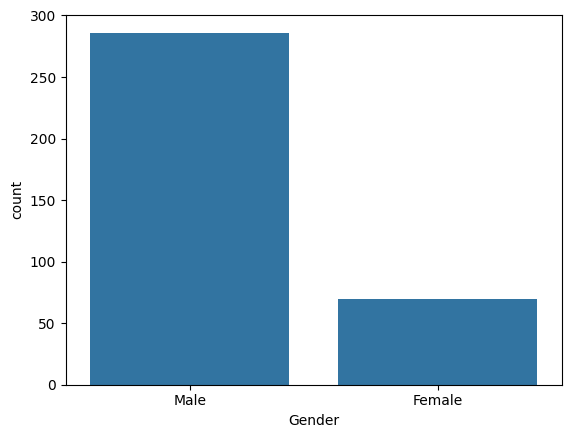

In [6]:
sns.countplot(x=df['Gender'])

In [7]:
#if any misisng value in gender column then fill it up with male
df['Gender'].mode()[0]

'Male'

In [8]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])

2.Married

<Axes: xlabel='Married', ylabel='count'>

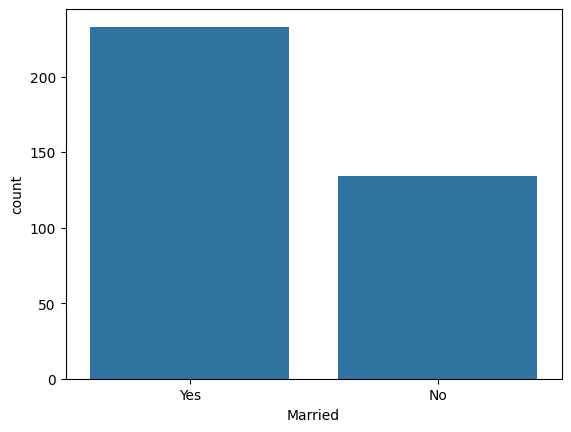

In [9]:
sns.countplot(x=df['Married'])

In [10]:
df['Married'].mode()[0]

'Yes'

In [11]:
df['Married']=df['Married'].fillna(df['Married'].mode()[0])

3.dependents

<Axes: xlabel='Dependents', ylabel='count'>

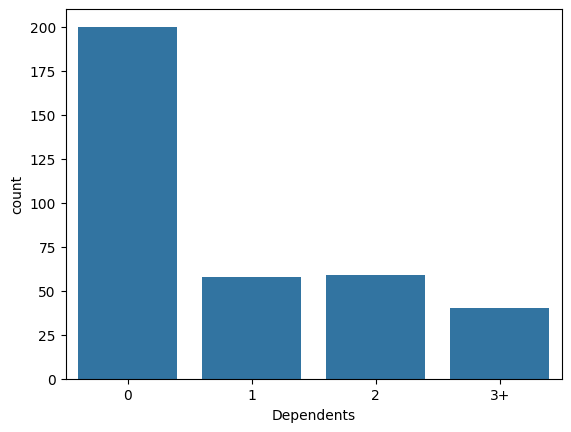

In [12]:
sns.countplot(x=df['Dependents'])

In [13]:
df['Dependents'].mode()[0]

'0'

In [14]:
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])

4.Self_Employed

<Axes: xlabel='Self_Employed', ylabel='count'>

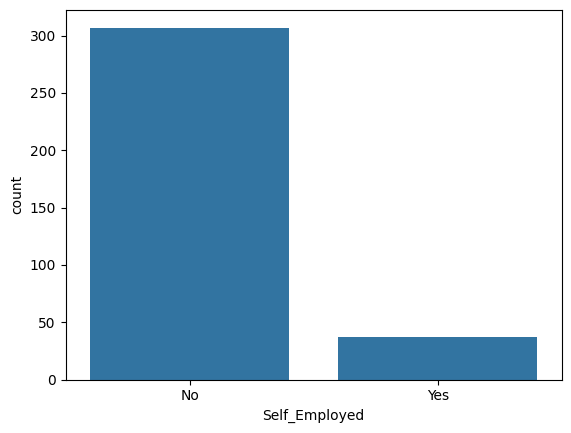

In [15]:
sns.countplot(x=df['Self_Employed'])

In [16]:
df['Self_Employed'].mode()[0]

'No'

In [17]:
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

5.LoanAmount

In [18]:
df['LoanAmount'].median()

np.float64(125.0)

In [19]:
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].median())

6.LoanAmountTerm

In [20]:
df['Loan_Amount_Term'].median()

np.float64(360.0)

In [21]:
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

7.Credit_History

<Axes: xlabel='Credit_History', ylabel='count'>

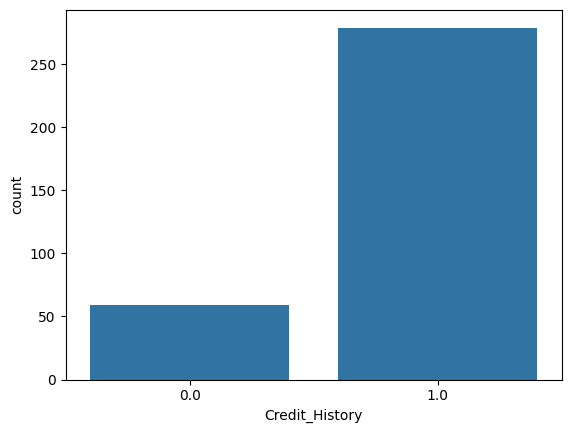

In [22]:
sns.countplot(x=df['Credit_History'])

In [23]:
df['Credit_History'].mode()[0]

np.float64(1.0)

In [24]:
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [25]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

step 4 - Feature Creation

In [26]:
df.replace({
    "Loan_Status":{'N':0,'Y':1},
    "Gender":{"Male":0,"Female":1},
    "Education":{'Not Graduate':0,'Graduate':1},
    "Married":{'No':0,'Yes':1},
    "Self_Employed":{'No':0,'Yes':1}  
},inplace=True)

In [27]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001015,0,1,0,1,0,5720,0,110.0,360.0,1.0,Urban,1
1,LP001022,0,1,1,1,0,3076,1500,126.0,360.0,1.0,Urban,0
2,LP001031,0,1,2,1,0,5000,1800,208.0,360.0,1.0,Urban,0
3,LP001035,0,1,2,1,0,2340,2546,100.0,360.0,1.0,Urban,0
4,LP001051,0,0,0,0,0,3276,0,78.0,360.0,1.0,Urban,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,0,1,3+,0,1,4009,1777,113.0,360.0,1.0,Urban,0
363,LP002975,0,1,0,1,0,4158,709,115.0,360.0,1.0,Urban,0
364,LP002980,0,0,0,1,0,3250,1993,126.0,360.0,1.0,Semiurban,0
365,LP002986,0,1,0,1,0,5000,2393,158.0,360.0,1.0,Rural,0


step 5 - train test split

In [28]:
def train_test_split_and_features(df):
    y = df['Loan_Status']
    x = df.drop(['Loan_Status', 'Loan_ID'], axis=1,errors='ignore')
    # Convert categorical variables
    x = pd.get_dummies(x, columns=["Property_Area", "Dependents"])
    # Split data
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0)
    # Store feature names
    features = list(x.columns)
    print(x.head(5))
    print(features)
    return x_train, x_test, y_train, y_test, features

In [29]:
x_train,x_test,y_train,y_test,features=train_test_split_and_features(df)

   Gender  Married  Education  Self_Employed  ApplicantIncome  \
0       0        1          1              0             5720   
1       0        1          1              0             3076   
2       0        1          1              0             5000   
3       0        1          1              0             2340   
4       0        0          0              0             3276   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0       110.0             360.0             1.0   
1               1500       126.0             360.0             1.0   
2               1800       208.0             360.0             1.0   
3               2546       100.0             360.0             1.0   
4                  0        78.0             360.0             1.0   

   Property_Area_Rural  Property_Area_Semiurban  Property_Area_Urban  \
0                False                    False                 True   
1                False                    Fa

step 6 - fit and evaluate model

In [30]:
def fit_and_evaluate_model(x_train, x_test, y_train, y_test):
    random_forest=RandomForestClassifier(random_state=0,\
                                          max_depth=5,\
                                          min_samples_split=0.01,\
                                          max_features=0.8,\
                                          max_samples=0.8)
    model=random_forest.fit(x_train,y_train)
    random_forest_predict=random_forest.predict(x_test)
    random_forest_conf_matrix=confusion_matrix(y_test,random_forest_predict)
    random_forest_acc_score=accuracy_score(y_test,random_forest_predict)
    print("confusion matrix")
    print(random_forest_conf_matrix)
    print("\n")
    print("accuracy of random forest:",random_forest_acc_score*100,'\n')
    print(classification_report(y_test,random_forest_predict))
    return model

In [31]:
model=fit_and_evaluate_model(x_train, x_test, y_train, y_test)

confusion matrix
[[62  0]
 [ 0 12]]


accuracy of random forest: 100.0 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        12

    accuracy                           1.00        74
   macro avg       1.00      1.00      1.00        74
weighted avg       1.00      1.00      1.00        74



In [32]:
importances=pd.DataFrame(model.feature_importances_)
importances['features']=features
importances.columns=['importance','features']
importances.sort_values(by='importance',ascending=True,inplace=True)

step 7 - feature importance

<BarContainer object of 16 artists>

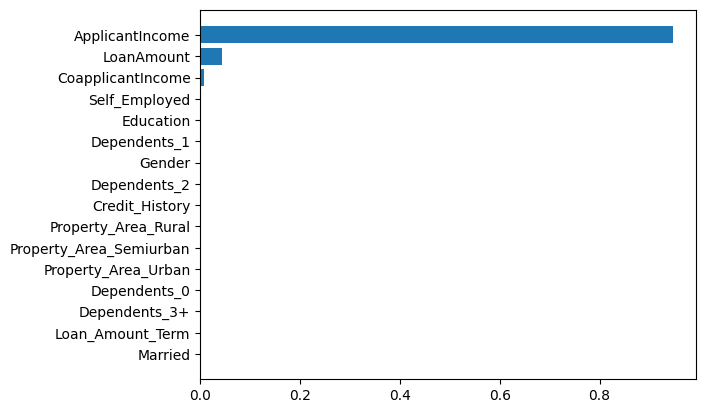

In [34]:
plt.barh(importances['features'],importances['importance'])

In [35]:
#prediction for each case

In [36]:
rf_proba=model.predict_proba(x_test)
rf_predict=model.predict(x_test)
print(rf_proba[0:10])
print(rf_predict)

[[1.   0.  ]
 [1.   0.  ]
 [0.99 0.01]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]]
[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 1 0 1 0 0
 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0]
